<a href="https://colab.research.google.com/github/MohamedElsayed002/Computer-Vision/blob/master/LeNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import keras
from keras.datasets import mnist
from keras.layers import Conv2D , MaxPooling2D
from keras.layers import Dense , Flatten , Dropout
from keras.models import Sequential
from keras.optimizers import SGD

# Loading Dataset

In [3]:
# Loading the dataset and perform splitting

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [4]:
# Max Pooling & ReLU

x_train.shape

(60000, 28, 28)

In [5]:
# Peforming reshaping operator

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normalization
x_train = x_train / 255
x_test = x_test / 255

# One Hot Encoding
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

In [7]:
# Building the Model Architecture.

model = Sequential()
model.add(Conv2D(6,kernel_size=(5,5),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(16,kernel_size=(5,5),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(120,activation='relu'))
model.add(Dense(84,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 6)         156       
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 6)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 16)          2416      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 4, 4, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 120)               3

In [9]:
model.compile(loss=keras.metrics.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])

In [10]:
model.fit(x_train,y_train,batch_size=128,epochs=20,verbose=1,validation_data=(x_test,y_test))

Epoch 1/20
469/469 [==============================] - 26s 52ms/step - loss: 0.3116 - accuracy: 0.9094 - val_loss: 0.0943 - val_accuracy: 0.9717
Epoch 2/20
469/469 [==============================] - 21s 44ms/step - loss: 0.0939 - accuracy: 0.9713 - val_loss: 0.0626 - val_accuracy: 0.9802
Epoch 3/20
469/469 [==============================] - 23s 50ms/step - loss: 0.0700 - accuracy: 0.9784 - val_loss: 0.0532 - val_accuracy: 0.9846
Epoch 4/20
469/469 [==============================] - 22s 48ms/step - loss: 0.0549 - accuracy: 0.9830 - val_loss: 0.0415 - val_accuracy: 0.9866
Epoch 5/20
469/469 [==============================] - 21s 44ms/step - loss: 0.0469 - accuracy: 0.9850 - val_loss: 0.0384 - val_accuracy: 0.9877
Epoch 6/20
469/469 [==============================] - 22s 47ms/step - loss: 0.0381 - accuracy: 0.9873 - val_loss: 0.0375 - val_accuracy: 0.9878
Epoch 7/20
469/469 [==============================] - 24s 52ms/step - loss: 0.0335 - accuracy: 0.9891 - val_loss: 0.0472 - val_accuracy:

In [12]:
score = model.evaluate(x_test,y_test)
print('Test Loss:',score[0])
print('Test Accuracy:', score[1])

313/313 [==============================] - 2s 6ms/step - loss: 0.0406 - accuracy: 0.9893
Test Loss: 0.04063909873366356
Test Accuracy: 0.989300012588501


In [13]:
# Save the Model

model.save('LeNet-5.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [17]:
from keras.models import load_model

# Load the model

loaded_model = load_model('LeNet-5.h5')

In [18]:
# Select a sample image from the test set

sample_index = 0
sample_image = x_test[sample_index]
sample_label = y_test[sample_index]

In [19]:
# Reshape the sample image to match the model input shae

sample_image = sample_image.reshape(1,28,28,1)

In [20]:
import numpy as np

# Predict the digit label for the sample image

predicted_label = loaded_model.predict(sample_image)
predicted_label = np.argmax(predicted_label)

1/1 [==============================] - 0s 122ms/step


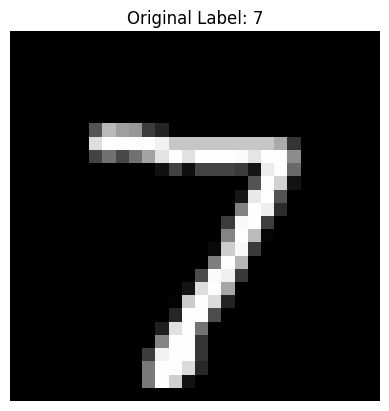

In [21]:
import matplotlib.pyplot as plt


# Display the original image

plt.imshow(sample_image.reshape(28,28),cmap='gray')
plt.title(f'Original Label: {np.argmax(sample_label)}')
plt.axis('off')
plt.show()

In [22]:
# Display the predicted label

print('Predicted Label:',predicted_label)

Predicted Label: 7


In [ ]:
# Alex Net Paper